# Geometrik & Spatial Filtering
Praktikum: Operasi Geometrik & Spatial Filtering

Notebook ini mendemonstrasikan operasi geometrik (scaling, rotation, flipping) dan spatial filtering (mean, gaussian, sharpening) menggunakan Python + OpenCV. Jalankan sel satu-persatu. Jika tidak memiliki `data/lenna.png`, notebook akan menggunakan gambar fallback dari `skimage.data`.

## 1. Setup environment
Jika library belum terpasang, jalankan perintah pip di bawah ini. (Uncomment baris pip jika perlu)

In [10]:
# Jika perlu, jalankan ini sekali untuk memasang dependency
# pip install --quiet opencv-python matplotlib scikit-image numpy

print("Pastikan opencv-python, matplotlib, scikit-image, numpy sudah terinstall.")


Pastikan opencv-python, matplotlib, scikit-image, numpy sudah terinstall.


## 2. Load image
Notebook mencoba memuat `data/lenna.png`. Jika tidak ada, gunakan gambar fallback dari `skimage.data`.

Using image: data/lenna.png


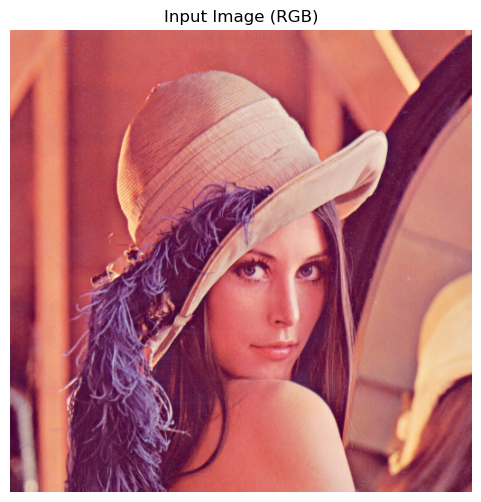

In [11]:
import os
import cv2
import numpy as np
from skimage import data, img_as_ubyte
import matplotlib.pyplot as plt

local_path = "data/lenna.png"
if os.path.exists(local_path):
    img_bgr = cv2.imread(local_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    source = local_path
else:
    img_gray = img_as_ubyte(data.camera())
    img_rgb = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    source = "skimage.data.camera() (fallback)"

print("Using image:", source)
plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title("Input Image (RGB)")
plt.axis('off')
plt.show()


## 3. Scaling (Resize)
Contoh: scaling up (fx=1.5, fy=1.5) dan scaling down (fx=0.5, fy=0.5).

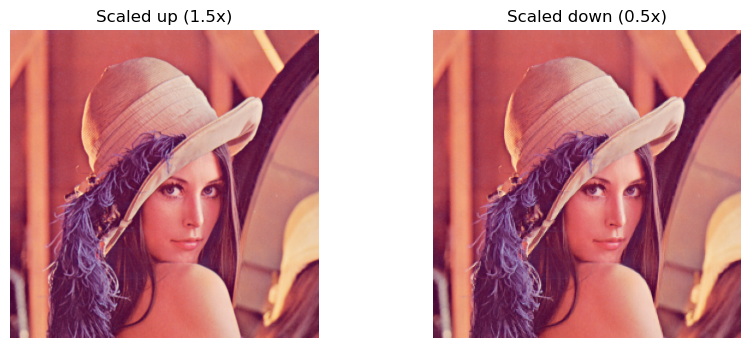

In [12]:
# Scaling examples
scaled_up = cv2.resize(img_rgb, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_LINEAR)
scaled_down = cv2.resize(img_rgb, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(scaled_up); plt.title('Scaled up (1.5x)'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(scaled_down); plt.title('Scaled down (0.5x)'); plt.axis('off')
plt.show()


## 4. Rotation
Putar citra 45° terhadap pusatnya menggunakan `cv2.getRotationMatrix2D` dan `cv2.warpAffine`. Juga tunjukkan rotasi dengan padding agar seluruh gambar terlihat.

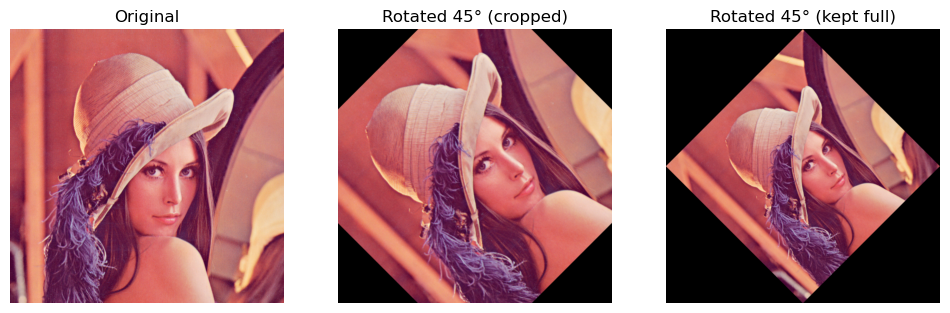

In [13]:
(h, w) = img_rgb.shape[:2]
angle = 45
scale = 1.0

# Rotation around center (may crop corners)
M = cv2.getRotationMatrix2D((w/2, h/2), angle, scale)
rotated = cv2.warpAffine(img_rgb, M, (w, h))

# Rotation with bounding to keep full image (compute new size)
import math
cos = abs(math.cos(math.radians(angle)))
sin = abs(math.sin(math.radians(angle)))
new_w = int(h * sin + w * cos)
new_h = int(h * cos + w * sin)

# adjust matrix to take into account translation
M2 = cv2.getRotationMatrix2D((w/2, h/2), angle, scale)
M2[0,2] += (new_w - w) / 2
M2[1,2] += (new_h - h) / 2
rotated_full = cv2.warpAffine(img_rgb, M2, (new_w, new_h))

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img_rgb); plt.title('Original'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(rotated); plt.title('Rotated 45° (cropped)'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(rotated_full); plt.title('Rotated 45° (kept full)'); plt.axis('off')
plt.show()


## 5. Flipping
Flip horizontal, vertical, dan both axes menggunakan `cv2.flip`.

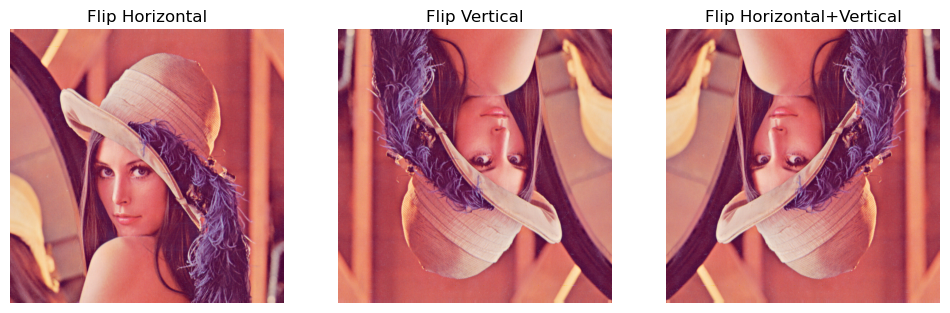

In [14]:
flip_h = cv2.flip(img_rgb, 1)   # horizontal
flip_v = cv2.flip(img_rgb, 0)   # vertical
flip_hv = cv2.flip(img_rgb, -1) # both

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(flip_h); plt.title('Flip Horizontal'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(flip_v); plt.title('Flip Vertical'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(flip_hv); plt.title('Flip Horizontal+Vertical'); plt.axis('off')
plt.show()


## 6. Spatial Filtering (Konvolusi)
Filtering = operasi konvolusi antara citra dan kernel. Kita akan praktekkan mean (average), gaussian, dan sharpening filter.

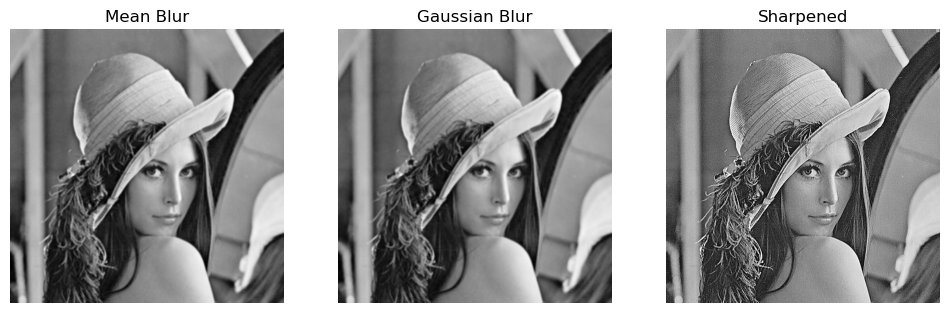

In [15]:
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Mean filter (average)
mean_blur = cv2.blur(img_gray, (3,3))

# Gaussian filter
gaussian_blur = cv2.GaussianBlur(img_gray, (5,5), 0)

# Sharpening (custom kernel)
kernel_sharp = np.array([[0, -1, 0],
                         [-1, 5,-1],
                         [0, -1, 0]])
sharpen = cv2.filter2D(img_gray, -1, kernel_sharp)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(mean_blur, cmap='gray'); plt.title('Mean Blur'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(gaussian_blur, cmap='gray'); plt.title('Gaussian Blur'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(sharpen, cmap='gray'); plt.title('Sharpened'); plt.axis('off')
plt.show()


## 7. Kernel Examples & Edge Detectors
Tampilkan kernel Sobel dan aplikasikan Sobel X/Y untuk perbandingan (tambahan kecil berkaitan dengan edge detection).

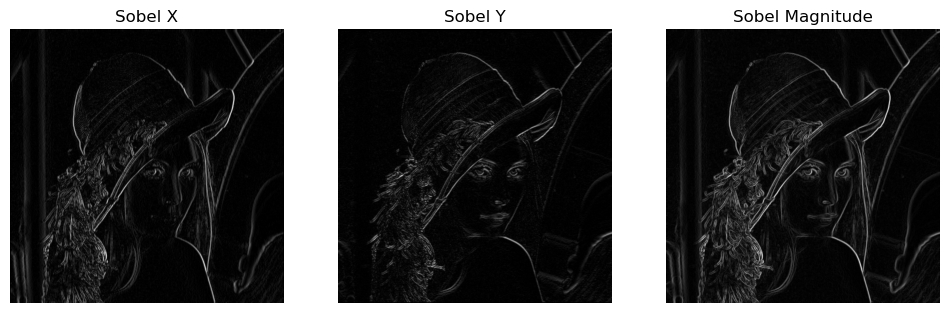

In [16]:
# Sobel kernels are applied via cv2.Sobel
sobelx = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = cv2.magnitude(sobelx, sobely)
sobel_mag_norm = cv2.normalize(sobel_mag, None, 0, 255, cv2.NORM_MINMAX).astype('uint8')

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(np.abs(sobelx), cmap='gray'); plt.title('Sobel X'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(np.abs(sobely), cmap='gray'); plt.title('Sobel Y'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(sobel_mag_norm, cmap='gray'); plt.title('Sobel Magnitude'); plt.axis('off')
plt.show()


## 8. Contoh Pipeline: Preprocessing untuk Deteksi
Contoh pipeline: resize -> rotate -> gaussian blur -> sobel untuk pra-pemrosesan sebelum ekstraksi fitur atau segmentasi.

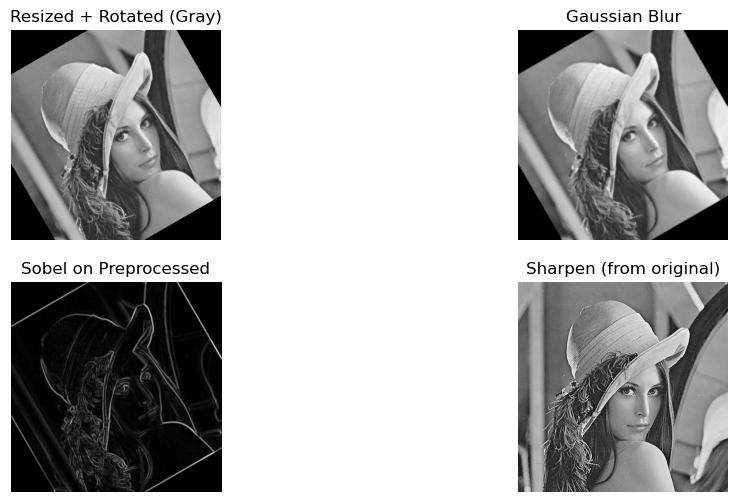

In [17]:
# Pipeline example
proc = cv2.resize(img_rgb, (512, 512))
(hp, wp) = proc.shape[:2]
M = cv2.getRotationMatrix2D((wp/2, hp/2), 30, 1.0)
proc = cv2.warpAffine(proc, M, (wp, hp))
proc_gray = cv2.cvtColor(proc, cv2.COLOR_RGB2GRAY)
proc_blur = cv2.GaussianBlur(proc_gray, (5,5), 0)
proc_sobel = cv2.Sobel(proc_blur, cv2.CV_64F, 1, 0, ksize=3)
proc_sobel_mag = cv2.magnitude(proc_sobel, cv2.Sobel(proc_blur, cv2.CV_64F, 0, 1, ksize=3))
proc_sobel_norm = cv2.normalize(proc_sobel_mag, None, 0, 255, cv2.NORM_MINMAX).astype('uint8')

plt.figure(figsize=(12,6))
plt.subplot(2,2,1); plt.imshow(cv2.cvtColor(proc, cv2.COLOR_RGB2GRAY), cmap='gray'); plt.title('Resized + Rotated (Gray)'); plt.axis('off')
plt.subplot(2,2,2); plt.imshow(proc_blur, cmap='gray'); plt.title('Gaussian Blur'); plt.axis('off')
plt.subplot(2,2,3); plt.imshow(proc_sobel_norm, cmap='gray'); plt.title('Sobel on Preprocessed'); plt.axis('off')
plt.subplot(2,2,4); plt.imshow(sharpen, cmap='gray'); plt.title('Sharpen (from original)'); plt.axis('off')
plt.show()


## 9. Latihan / Tugas
1. Ubah faktor scaling dan bandingkan hasil interpolasi (INTER_LINEAR vs INTER_AREA vs INTER_CUBIC).
2. Eksperimen dengan sudut rotasi berbeda dan perhatikan perbedaan cropping vs keeping full image.
3. Ubah kernel sharpening dan bandingkan efek pada detail.
4. Gabungkan transformasi geometrik dan filtering untuk meningkatkan hasil deteksi tepi pada citra noisy.